# 🏦 Prêt à Dépenser — Scoring Crédit
## Étape 2 : Tracking des expérimentations avec MLflow

**Objectif :** Entraîner et comparer plusieurs modèles de scoring, tracker chaque expérimentation avec MLflow (paramètres, métriques, artefacts), et stocker les modèles dans le Model Registry.

| Section | Description |
|---------|-------------|
| 0 | Configuration & imports |
| 1 | Chargement des données préparées |
| 2 | Configuration MLflow |
| 3 | Fonctions utilitaires (score métier, seuil optimal) |
| 4 | Modèle 1 — Régression Logistique (baseline) |
| 5 | Modèle 2 — LightGBM (modèle principal) |
| 6 | Modèle 3 — XGBoost (challenger) |
| 7 | Comparaison des modèles & sélection |
| 8 | Enregistrement dans le Model Registry |

> **Prérequis :** Avoir exécuté l'étape 1 et disposer de `output/train_prepared.csv` et `output/test_prepared.csv`
>
> **Lancer l'UI MLflow :** `mlflow ui` dans un terminal, puis ouvrir http://localhost:5000


---
## ⚙️ 0. Configuration & Imports

In [1]:
import sys
print(sys.executable)

import mlflow.tracking._tracking_service.utils as utils
print(utils._tracking_store_registry._registry.keys())

/Users/diagabatekoffi/PycharmProjects/MlProject/.venv/bin/python
dict_keys(['', 'file', 'databricks', 'databricks-uc', 'uc', 'http', 'https', 'postgresql', 'mysql', 'sqlite', 'mssql'])


In [2]:
# Installation des dépendances (décommenter si besoin)
# !pip install mlflow lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.xgboost

# Modèles
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Évaluation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# ── Chemins ───────────────────────────────────────────────────────
OUTPUT_DIR  = "../output"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
MLFLOW_DIR  = "../mlruns"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

print("✅ Configuration OK")
print(f"   MLflow version : {mlflow.__version__}")


✅ Configuration OK
   MLflow version : 3.15.0


In [3]:
train = pd.read_csv(os.path.join(OUTPUT_DIR, "train_prepared.csv"))
test  = pd.read_csv(os.path.join(OUTPUT_DIR, "test_prepared.csv"))

print(f"Train : {train.shape[0]:,} lignes × {train.shape[1]:,} colonnes")
print(f"Test  : {test.shape[0]:,} lignes × {test.shape[1]:,} colonnes")
print(f"Défauts (TARGET=1) : {train['TARGET'].sum():,} ({train['TARGET'].mean()*100:.1f}%)")

# ── Suppression des redondances identifiées en étape 1 ───────────
# DAYS_BIRTH == -AGE_YEARS*365  |  DAYS_EMPLOYED == -EMPLOYED_YEARS*365
# INS_IS_LATE_MEAN == INS_LATE_RATE  → corrélation 1.0 confirmée
COLS_REDUNDANT = ["DAYS_BIRTH", "DAYS_EMPLOYED", "INS_IS_LATE_MEAN"]
cols_to_drop = [c for c in COLS_REDUNDANT if c in train.columns]
train = train.drop(columns=cols_to_drop)
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])
print(f"\n  Colonnes redondantes supprimées : {cols_to_drop}")

# ── Séparation features / target ──────────────────────────────────
X = train.drop(columns=["SK_ID_CURR", "TARGET"])
y = train["TARGET"]
X_test_final = test.drop(columns=["SK_ID_CURR"], errors="ignore")

print(f"\n  X train : {X.shape}")
print(f"  X test  : {X_test_final.shape}")


Train : 307,511 lignes × 730 colonnes
Test  : 48,744 lignes × 729 colonnes
Défauts (TARGET=1) : 24,825 (8.1%)

  Colonnes redondantes supprimées : ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'INS_IS_LATE_MEAN']

  X train : (307511, 725)
  X test  : (48744, 725)


In [4]:
import mlflow
import os

# MLflow 3.x — syntaxe SQLite correcte
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")

EXPERIMENT_NAME = "scoring_credit_pret_a_depenser"
mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"Experiment : {EXPERIMENT_NAME}")
print(f"ID         : {exp.experiment_id}")
print("\n✅ MLflow configuré")

Tracking URI : sqlite:///mlflow.db
Experiment : scoring_credit_pret_a_depenser
ID         : 2

✅ MLflow configuré


---
## 🧮 3. Fonctions utilitaires — Score métier & Seuil optimal

### Rappel de la formule métier (Michaël)

$$\text{coût}(seuil) = 10 \times FN(seuil) + 1 \times FP(seuil)$$

- **FN** (Faux Négatif) : mauvais client prédit bon → crédit accordé → **perte en capital** (coût ×10)
- **FP** (Faux Positif) : bon client prédit mauvais → crédit refusé → **manque à gagner** (coût ×1)

Le seuil optimal **n'est pas 0.5** — on le cherche en balayant tous les seuils possibles.


In [5]:
def cout_metier(y_true, y_proba, seuil, cout_fn=10, cout_fp=1):
    """
    Calcule le coût métier pour un seuil donné.
    FN coûte cout_fn fois plus qu'un FP.
    """
    y_pred = (y_proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cout_fn * fn + cout_fp * fp


def seuil_optimal(y_true, y_proba, cout_fn=10, cout_fp=1, n_steps=200):
    """
    Trouve le seuil qui minimise le coût métier.
    Retourne (seuil_optimal, coût_min, liste des coûts par seuil).
    """
    seuils = np.linspace(0.01, 0.99, n_steps)
    couts  = [cout_metier(y_true, y_proba, s, cout_fn, cout_fp) for s in seuils]
    idx    = np.argmin(couts)
    return seuils[idx], couts[idx], seuils, couts


def evaluer_modele(y_true, y_proba, seuil=None, label=""):
    """
    Calcule toutes les métriques : AUC, accuracy, F1, score métier.
    Retourne un dict de métriques et le seuil optimal.
    """
    seuil_opt, cout_min, seuils, couts = seuil_optimal(y_true, y_proba)
    if seuil is None:
        seuil = seuil_opt

    y_pred = (y_proba >= seuil).astype(int)
    auc    = roc_auc_score(y_true, y_proba)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred)
    cout   = cout_metier(y_true, y_proba, seuil)

    if label:
        print(f"  {label}")
        print(f"    AUC-ROC        : {auc:.4f}")
        print(f"    Accuracy       : {acc:.4f}")
        print(f"    F1-score       : {f1:.4f}")
        print(f"    Seuil optimal  : {seuil_opt:.3f}  (vs 0.5 par défaut)")
        print(f"    Coût métier    : {cout_min:,.0f}  (10×FN + 1×FP)")

    return {
        "auc"         : auc,
        "accuracy"    : acc,
        "f1"          : f1,
        "cout_metier" : cout_min,
        "seuil_opt"   : seuil_opt,
    }, seuils, couts


def plot_courbe_cout(seuils, couts, seuil_opt, titre, path=None):
    """Trace la courbe coût métier en fonction du seuil."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(seuils, couts, color="#378ADD", lw=2)
    ax.axvline(seuil_opt, color="#D85A30", ls="--", lw=1.5,
               label=f"Seuil optimal = {seuil_opt:.3f}")
    ax.axvline(0.5, color="#888780", ls=":", lw=1.2, label="Seuil 0.5 (défaut)")
    ax.set_xlabel("Seuil de classification")
    ax.set_ylabel("Coût métier (10×FN + 1×FP)")
    ax.set_title(titre)
    ax.legend()
    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.show()

print("✅ Fonctions utilitaires définies")
print("   cout_metier()  — calcule le coût pour un seuil")
print("   seuil_optimal() — trouve le seuil qui minimise le coût")
print("   evaluer_modele() — toutes les métriques en un appel")


✅ Fonctions utilitaires définies
   cout_metier()  — calcule le coût pour un seuil
   seuil_optimal() — trouve le seuil qui minimise le coût
   evaluer_modele() — toutes les métriques en un appel


---
## 📊 4. Modèle 1 — Régression Logistique (baseline)

La régression logistique sert de **baseline** : simple, rapide, interprétable.
Elle nécessite une normalisation des features (`StandardScaler`).

**Gestion du déséquilibre :** `class_weight="balanced"` → pondère automatiquement
les défauts 11× plus que les bons clients.


In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── StratifiedKFold ───────────────────────────────────────────────
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Réduction des features pour la baseline ───────────────────────
correlations  = X.corrwith(y).abs().sort_values(ascending=False)
TOP_FEATURES  = correlations.head(100).index.tolist()
X_lr = X[TOP_FEATURES]
print(f"Features pour LogReg : {X_lr.shape[1]} (au lieu de {X.shape[1]})")

print("=" * 55)
print("  MODÈLE 1 — Régression Logistique (baseline)")
print("=" * 55)

LR_PARAMS = {
    "C"            : 0.01,
    "max_iter"     : 500,       # réduit de 1000 à 500
    "class_weight" : "balanced",
    "solver"       : "saga",
    "n_jobs"       : -1,        # parallélisation
    "random_state" : 42,
}

with mlflow.start_run(run_name="LogisticRegression_baseline") as run:

    mlflow.set_tags({
        "modele"      : "LogisticRegression",
        "etape"       : "baseline",
        "dataset"     : "home_credit",
        "desequilibre": "class_weight_balanced",
    })
    mlflow.log_params(LR_PARAMS)
    mlflow.log_param("n_features_used", len(TOP_FEATURES))

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(**LR_PARAMS))
    ])

    aucs, f1s, couts, seuils_opts = [], [], [], []

    for fold, (idx_tr, idx_val) in enumerate(SKF.split(X_lr, y), 1):
        X_tr,  X_val = X_lr.iloc[idx_tr], X_lr.iloc[idx_val]
        y_tr,  y_val = y.iloc[idx_tr],    y.iloc[idx_val]

        pipeline.fit(X_tr, y_tr)
        y_proba = pipeline.predict_proba(X_val)[:, 1]
        metriques, _, _ = evaluer_modele(y_val, y_proba)

        aucs.append(metriques["auc"])
        f1s.append(metriques["f1"])
        couts.append(metriques["cout_metier"])
        seuils_opts.append(metriques["seuil_opt"])

        mlflow.log_metric("fold_auc",         metriques["auc"],         step=fold)
        mlflow.log_metric("fold_f1",          metriques["f1"],          step=fold)
        mlflow.log_metric("fold_cout_metier", metriques["cout_metier"], step=fold)
        mlflow.log_metric("fold_seuil_opt",   metriques["seuil_opt"],   step=fold)

        print(f"  Fold {fold} — AUC: {metriques['auc']:.4f} | "
              f"F1: {metriques['f1']:.4f} | "
              f"Coût: {metriques['cout_metier']:,.0f} | "
              f"Seuil: {metriques['seuil_opt']:.3f}")

    mean_auc  = np.mean(aucs)
    std_auc   = np.std(aucs)
    mean_f1   = np.mean(f1s)
    mean_cout = np.mean(couts)
    seuil_moy = np.mean(seuils_opts)

    mlflow.log_metrics({
        "mean_auc"        : mean_auc,
        "std_auc"         : std_auc,
        "mean_f1"         : mean_f1,
        "mean_cout_metier": mean_cout,
        "seuil_optimal"   : seuil_moy,
    })

    print(f"\n  → AUC moyen   : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"  → F1 moyen    : {mean_f1:.4f}")
    print(f"  → Coût moyen  : {mean_cout:,.0f}")
    print(f"  → Seuil opt.  : {seuil_moy:.3f}")

    # Entraînement final
    pipeline.fit(X_lr, y)
    mlflow.sklearn.log_model(pipeline, "model",
                             registered_model_name="scoring_credit_logreg")
    LR_RUN_ID = run.info.run_id
    print(f"\n  ✅ Run ID : {LR_RUN_ID}")

Features pour LogReg : 100 (au lieu de 725)
  MODÈLE 1 — Régression Logistique (baseline)
  Fold 1 — AUC: 0.7623 | F1: 0.2847 | Coût: 31,738 | Seuil: 0.527
  Fold 2 — AUC: 0.7683 | F1: 0.2805 | Coût: 31,757 | Seuil: 0.517
  Fold 3 — AUC: 0.7629 | F1: 0.2819 | Coût: 32,114 | Seuil: 0.532
  Fold 4 — AUC: 0.7668 | F1: 0.2720 | Coût: 31,758 | Seuil: 0.488
  Fold 5 — AUC: 0.7594 | F1: 0.2758 | Coût: 32,415 | Seuil: 0.517

  → AUC moyen   : 0.7639 ± 0.0032
  → F1 moyen    : 0.2790
  → Coût moyen  : 31,956
  → Seuil opt.  : 0.516


2026/07/31 23:56:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  ✅ Run ID : b3e4450c78fc403280e53171581a9c3e


Registered model 'scoring_credit_logreg' already exists. Creating a new version of this model...
Created version '2' of model 'scoring_credit_logreg'.


---
## 🌲 5. Modèle 2 — LightGBM (modèle principal)

LightGBM est le modèle principal : rapide, performant sur données tabulaires déséquilibrées.

**Gestion du déséquilibre :** `scale_pos_weight = n_négatifs / n_positifs ≈ 11.4`
→ Le modèle pénalise plus fortement les erreurs sur la classe minoritaire.

**Optimisation des hyperparamètres :** GridSearchCV sur les paramètres clés.


In [7]:
import re
from sklearn.model_selection import StratifiedShuffleSplit

# ── Nettoyage des noms de colonnes pour LightGBM ─────────────────
def clean_col_names(df):
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

X = clean_col_names(X)

# ── Top 200 features ──────────────────────────────────────────────
correlations      = X.corrwith(y).abs().sort_values(ascending=False)
TOP_FEATURES_LGBM = correlations.head(200).index.tolist()
X_lgbm            = X[TOP_FEATURES_LGBM]
print(f"✅ X_lgbm : {X_lgbm.shape[1]} features")

# ── Échantillon 10% pour GridSearch ──────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=42)
idx_sample, _ = next(sss.split(X_lgbm, y))
X_sample = X_lgbm.iloc[idx_sample]
y_sample = y.iloc[idx_sample]
print(f"✅ X_sample : {len(X_sample):,} clients (10%)")

✅ X_lgbm : 200 features
✅ X_sample : 30,751 clients (10%)


In [8]:
from sklearn.model_selection import GridSearchCV

scale_pw = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight = {scale_pw:.2f}  (ratio bon/défaut)")


# ── Grid élargi pour améliorer LightGBM ──────────────────────────
LGBM_GRID = {
    "n_estimators" : [500],
    "learning_rate": [0.02],
    "num_leaves"   : [63],
    "min_child_samples": [20],
}
# 1 combinaison × 3 folds = 3 fits seulement
# 16 combinaisons × 3 folds = 48 fits
print(f"Grid : {np.prod([len(v) for v in LGBM_GRID.values()])} combinaisons")
# 2 combinaisons × 3 folds = 6 fits seulement
# 4 combinaisons × 3 folds = 12 fits au lieu de 48

LGBM_BASE = LGBMClassifier(
    scale_pos_weight = scale_pw,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
    subsample        = 0.8,           # utilise 80% des données par arbre
    colsample_bytree = 0.8,           # utilise 80% des features par arbre
)

# GridSearch sur un échantillon pour aller plus vite
from sklearn.model_selection import GridSearchCV
import numpy as np

# Échantillon stratifié 30% pour le GridSearch uniquement
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=42)
idx_sample, _ = next(sss.split(X_lgbm, y))
X_sample = X_lgbm.iloc[idx_sample]
y_sample = y.iloc[idx_sample]
print(f"GridSearch sur {len(X_sample):,} clients (10%)")

grid_search = GridSearchCV(
    LGBM_BASE,
    LGBM_GRID,
    cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring = "roc_auc",
    n_jobs  = 1,        # ← 1 seul CPU pour éviter le MemoryError
    verbose = 1,
    refit   = True,
)
grid_search.fit(X_sample, y_sample)

best_params = grid_search.best_params_
print(f"\n✅ Meilleurs paramètres : {best_params}")
print(f"   Meilleur AUC CV      : {grid_search.best_score_:.4f}")


scale_pos_weight = 11.39  (ratio bon/défaut)
Grid : 1 combinaisons
GridSearch sur 30,751 clients (10%)
Fitting 3 folds for each of 1 candidates, totalling 3 fits

✅ Meilleurs paramètres : {'learning_rate': 0.02, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 63}
   Meilleur AUC CV      : 0.7457


In [9]:
# ── Réduction features pour LightGBM ─────────────────────────────
# On garde les 200 features les plus corrélées avec TARGET
# LightGBM est plus rapide avec moins de features sans perdre en qualité

correlations  = X.corrwith(y).abs().sort_values(ascending=False)
TOP_FEATURES_LGBM = correlations.head(200).index.tolist()

X_lgbm = X[TOP_FEATURES_LGBM]
X_sample_lgbm = X_sample[TOP_FEATURES_LGBM]

print(f"Features pour LightGBM : {X_lgbm.shape[1]} (au lieu de {X.shape[1]})")

Features pour LightGBM : 200 (au lieu de 725)


  MODÈLE 2 — LightGBM (modèle principal)
  Fold 1 — AUC: 0.7393 | F1: 0.2636 | Coût: 34,253 | Seuil: 0.108
  Fold 2 — AUC: 0.7415 | F1: 0.2641 | Coût: 33,674 | Seuil: 0.108
  Fold 3 — AUC: 0.7380 | F1: 0.2606 | Coût: 34,408 | Seuil: 0.108
  Fold 4 — AUC: 0.7443 | F1: 0.2683 | Coût: 33,345 | Seuil: 0.108
  Fold 5 — AUC: 0.7321 | F1: 0.2620 | Coût: 34,374 | Seuil: 0.108

  → AUC moyen   : 0.7390 ± 0.0041
  → F1 moyen    : 0.2637
  → Coût moyen  : 34,011
  → Seuil opt.  : 0.108


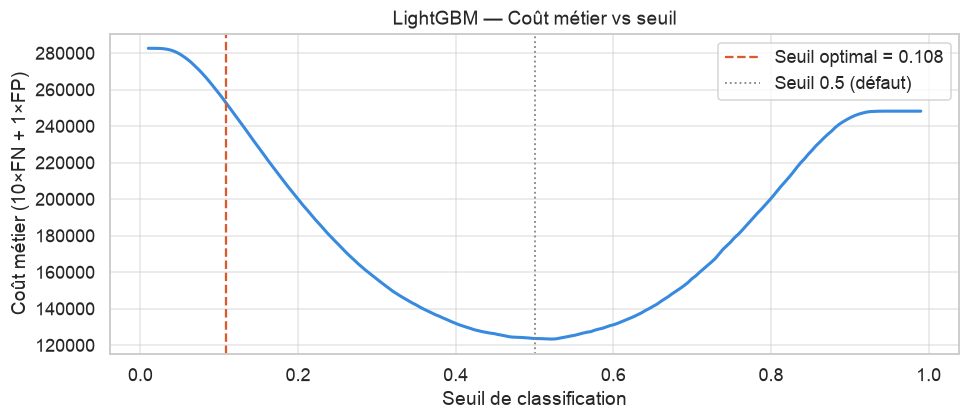

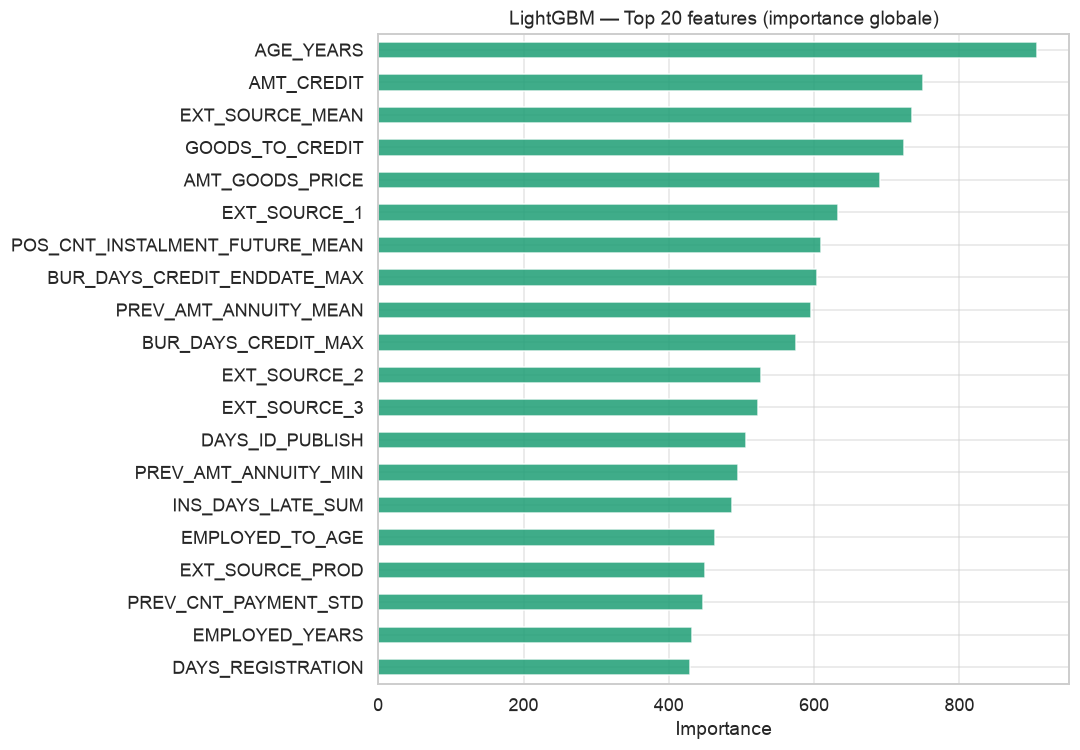

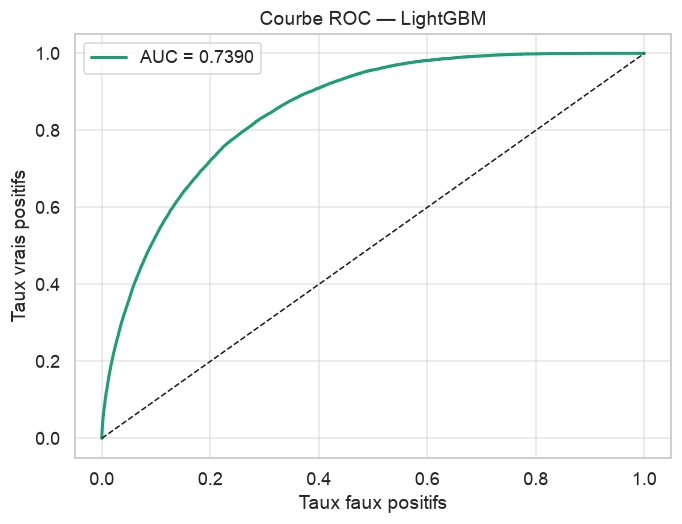

2026/08/01 00:00:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  ✅ Run ID : 84606ec75a3e49d5a5c0ba90750e9f08
  Modèle enregistré : scoring_credit_lgbm


Registered model 'scoring_credit_lgbm' already exists. Creating a new version of this model...
Created version '2' of model 'scoring_credit_lgbm'.


In [10]:
from lightgbm import early_stopping, log_evaluation

print("=" * 55)
print("  MODÈLE 2 — LightGBM (modèle principal)")
print("=" * 55)

with mlflow.start_run(run_name="LightGBM_gridsearch") as run:

    # ── Tags ──────────────────────────────────────────────────────
    mlflow.set_tags({
        "modele"       : "LightGBM",
        "etape"        : "principal",
        "dataset"      : "home_credit",
        "auteur"       : "data_scientist",
        "desequilibre" : "scale_pos_weight",
        "optimisation" : "GridSearchCV_3folds",
    })

    # ── Paramètres ────────────────────────────────────────────────
    all_params = {**best_params,
                  "scale_pos_weight": scale_pw,
                  "random_state": 42, "n_jobs": 1}
    mlflow.log_params(all_params)
    mlflow.log_param("n_folds_eval",  5)
    mlflow.log_param("n_folds_grid",  3)
    mlflow.log_param("n_features",    X_lgbm.shape[1])
    mlflow.log_param("grid_best_auc", grid_search.best_score_)

    # ── Modèle avec meilleurs HP ──────────────────────────────────
    lgbm = LGBMClassifier(
        **best_params,
        scale_pos_weight = scale_pw,
        random_state     = 42,
        n_jobs           = 1,
        verbose          = -1,
    )

    # ── Cross-validation 5 folds ──────────────────────────────────
    aucs, accs, f1s, couts, seuils_opts = [], [], [], [], []

    for fold, (idx_tr, idx_val) in enumerate(SKF.split(X_lgbm, y), 1):
        X_tr, X_val = X_lgbm.iloc[idx_tr], X_lgbm.iloc[idx_val]
        y_tr, y_val = y.iloc[idx_tr],      y.iloc[idx_val]

        lgbm.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                early_stopping(50, verbose=False),
                log_evaluation(-1)
            ]
        )

        y_proba = lgbm.predict_proba(X_val)[:, 1]
        metriques, _, _ = evaluer_modele(y_val, y_proba)

        aucs.append(metriques["auc"])
        accs.append(metriques["accuracy"])
        f1s.append(metriques["f1"])
        couts.append(metriques["cout_metier"])
        seuils_opts.append(metriques["seuil_opt"])

        mlflow.log_metric("fold_auc",         metriques["auc"],         step=fold)
        mlflow.log_metric("fold_accuracy",    metriques["accuracy"],    step=fold)
        mlflow.log_metric("fold_f1",          metriques["f1"],          step=fold)
        mlflow.log_metric("fold_cout_metier", metriques["cout_metier"], step=fold)
        mlflow.log_metric("fold_seuil_opt",   metriques["seuil_opt"],   step=fold)

        print(f"  Fold {fold} — AUC: {metriques['auc']:.4f} | "
              f"F1: {metriques['f1']:.4f} | "
              f"Coût: {metriques['cout_metier']:,.0f} | "
              f"Seuil: {metriques['seuil_opt']:.3f}")

    mean_auc  = np.mean(aucs)
    std_auc   = np.std(aucs)
    mean_f1   = np.mean(f1s)
    mean_cout = np.mean(couts)
    seuil_moy = np.mean(seuils_opts)

    mlflow.log_metrics({
        "mean_auc"        : mean_auc,
        "std_auc"         : std_auc,
        "mean_accuracy"   : np.mean(accs),
        "mean_f1"         : mean_f1,
        "mean_cout_metier": mean_cout,
        "seuil_optimal"   : seuil_moy,
    })

    print(f"\n  → AUC moyen   : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"  → F1 moyen    : {mean_f1:.4f}")
    print(f"  → Coût moyen  : {mean_cout:,.0f}")
    print(f"  → Seuil opt.  : {seuil_moy:.3f}")

    if mean_auc > 0.82:
        print("  ⚠️  AUC > 0.82 — vérifier l'overfitting !")

    # ── Entraînement final sur tout le train ──────────────────────
    lgbm.fit(X_lgbm, y)
    y_proba_full = lgbm.predict_proba(X_lgbm)[:, 1]
    _, seuils_full, couts_full = evaluer_modele(y, y_proba_full)

    # ── Courbe coût métier ────────────────────────────────────────
    path_cout = os.path.join(FIGURES_DIR, "lgbm_cout_metier.png")
    plot_courbe_cout(seuils_full, couts_full, seuil_moy,
                     "LightGBM — Coût métier vs seuil", path_cout)
    mlflow.log_artifact(path_cout, "figures")

    # ── Feature importance top 20 ─────────────────────────────────
    feat_imp = pd.Series(lgbm.feature_importances_, index=X_lgbm.columns)
    top20    = feat_imp.nlargest(20)
    fig, ax  = plt.subplots(figsize=(10, 7))
    top20.sort_values().plot.barh(ax=ax, color="#1D9E75", alpha=0.85)
    ax.set_title("LightGBM — Top 20 features (importance globale)")
    ax.set_xlabel("Importance")
    path_imp = os.path.join(FIGURES_DIR, "lgbm_feature_importance.png")
    plt.tight_layout(); plt.savefig(path_imp); plt.show()
    mlflow.log_artifact(path_imp, "figures")

    # ── Courbe ROC ────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y, y_proba_full)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#1D9E75", lw=2, label=f"AUC = {mean_auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("Taux faux positifs")
    ax.set_ylabel("Taux vrais positifs")
    ax.set_title("Courbe ROC — LightGBM")
    ax.legend()
    path_roc = os.path.join(FIGURES_DIR, "lgbm_roc.png")
    plt.savefig(path_roc); plt.show()
    mlflow.log_artifact(path_roc, "figures")

    # ── Log du modèle ─────────────────────────────────────────────
    mlflow.lightgbm.log_model(
        lgbm,
        artifact_path          = "model",
        registered_model_name  = "scoring_credit_lgbm",
        input_example          = X_lgbm.head(3),
    )

    LGBM_RUN_ID   = run.info.run_id
    LGBM_MODEL    = lgbm
    LGBM_SEUIL    = seuil_moy
    LGBM_MEAN_AUC = mean_auc

    print(f"\n  ✅ Run ID : {LGBM_RUN_ID}")
    print(f"  Modèle enregistré : scoring_credit_lgbm")

---
## ⚡ 6. Modèle 3 — XGBoost (challenger)

XGBoost est le challenger : même famille que LightGBM mais algorithme différent.
On utilise `scale_pos_weight` identique et un GridSearch rapide.


In [11]:
# ── Grid XGBoost ──────────────────────────────────────────────────
XGB_GRID = {
    "n_estimators" : [300, 500],
    "learning_rate": [0.05, 0.01],
    "max_depth"    : [4, 6],
}

XGB_BASE = XGBClassifier(
    scale_pos_weight = scale_pw,
    random_state     = 42,
    n_jobs           = -1,
    eval_metric      = "auc",
    verbosity        = 0,
    use_label_encoder= False,
)

grid_xgb = GridSearchCV(
    XGB_BASE, XGB_GRID,
    cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring = "roc_auc",
    n_jobs  = -1, verbose=1,
)
grid_xgb.fit(X, y)
best_params_xgb = grid_xgb.best_params_
print(f"Meilleurs paramètres XGB : {best_params_xgb}")
print(f"Meilleur AUC CV          : {grid_xgb.best_score_:.4f}")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs paramètres XGB : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500}
Meilleur AUC CV          : 0.7820


  MODÈLE 3 — XGBoost (challenger)
  Fold 1 — AUC: 0.7814 | F1: 0.2989 | Coût: 30,311 | Seuil: 0.512
  Fold 2 — AUC: 0.7881 | F1: 0.2976 | Coût: 29,775 | Seuil: 0.498
  Fold 3 — AUC: 0.7804 | F1: 0.2983 | Coût: 30,296 | Seuil: 0.512
  Fold 4 — AUC: 0.7867 | F1: 0.2989 | Coût: 29,741 | Seuil: 0.498
  Fold 5 — AUC: 0.7799 | F1: 0.2853 | Coût: 30,914 | Seuil: 0.483

  → AUC moyen   : 0.7833 ± 0.0034
  → F1 moyen    : 0.2958
  → Coût moyen  : 30,207
  → Seuil opt.  : 0.500


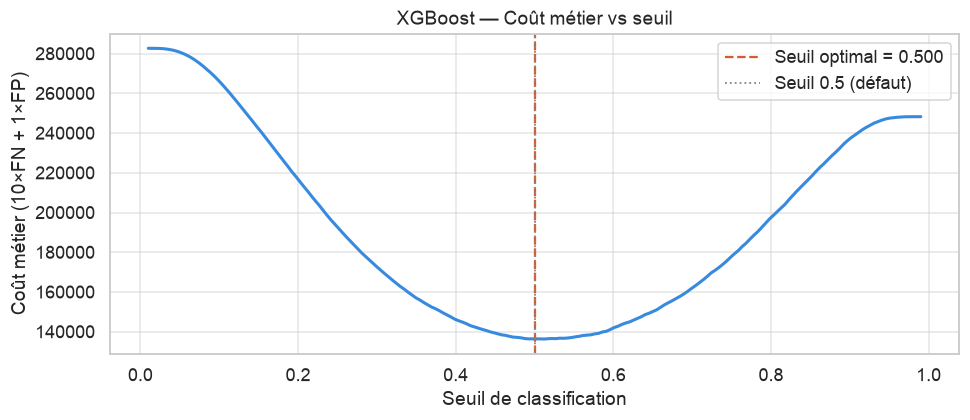

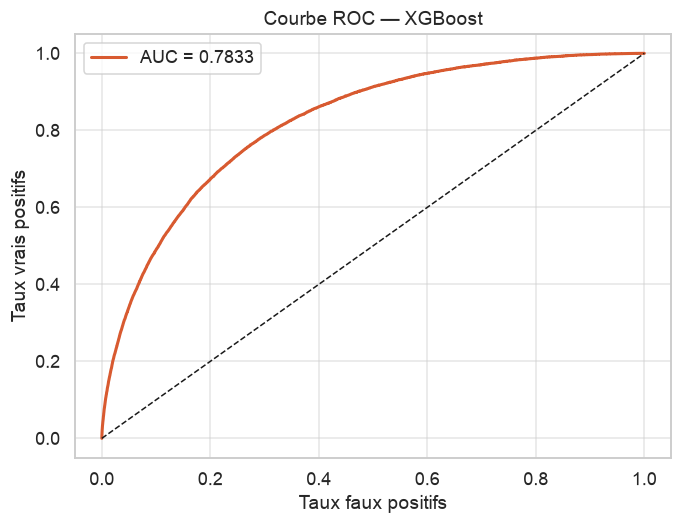

2026/08/01 00:20:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  ✅ Run ID : 1e9fbee4de474abb8802422c044ea752
  Modèle enregistré : scoring_credit_xgb


Registered model 'scoring_credit_xgb' already exists. Creating a new version of this model...
Created version '2' of model 'scoring_credit_xgb'.


In [12]:
print("=" * 55)
print("  MODÈLE 3 — XGBoost (challenger)")
print("=" * 55)

with mlflow.start_run(run_name="XGBoost_gridsearch") as run:

    mlflow.set_tags({
        "modele"      : "XGBoost",
        "etape"       : "challenger",
        "dataset"     : "home_credit",
        "auteur"      : "data_scientist",
        "desequilibre": "scale_pos_weight",
        "optimisation": "GridSearchCV_3folds",
    })

    all_params_xgb = {**best_params_xgb,
                      "scale_pos_weight": scale_pw,
                      "random_state": 42, "verbosity": 0}
    mlflow.log_params(all_params_xgb)
    mlflow.log_param("grid_best_auc", grid_xgb.best_score_)

    xgb = XGBClassifier(**all_params_xgb, use_label_encoder=False, eval_metric="auc")

    aucs, accs, f1s, couts, seuils_opts = [], [], [], [], []

    for fold, (idx_tr, idx_val) in enumerate(SKF.split(X, y), 1):
        X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
        y_tr, y_val = y.iloc[idx_tr], y.iloc[idx_val]

        xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        y_proba = xgb.predict_proba(X_val)[:, 1]
        metriques, _, _ = evaluer_modele(y_val, y_proba)

        aucs.append(metriques["auc"])
        accs.append(metriques["accuracy"])
        f1s.append(metriques["f1"])
        couts.append(metriques["cout_metier"])
        seuils_opts.append(metriques["seuil_opt"])

        mlflow.log_metric("fold_auc",         metriques["auc"],         step=fold)
        mlflow.log_metric("fold_accuracy",    metriques["accuracy"],    step=fold)
        mlflow.log_metric("fold_f1",          metriques["f1"],          step=fold)
        mlflow.log_metric("fold_cout_metier", metriques["cout_metier"], step=fold)
        mlflow.log_metric("fold_seuil_opt",   metriques["seuil_opt"],   step=fold)

        print(f"  Fold {fold} — AUC: {metriques['auc']:.4f} | "
              f"F1: {metriques['f1']:.4f} | "
              f"Coût: {metriques['cout_metier']:,.0f} | "
              f"Seuil: {metriques['seuil_opt']:.3f}")

    mean_auc  = np.mean(aucs)
    std_auc   = np.std(aucs)
    mean_f1   = np.mean(f1s)
    mean_cout = np.mean(couts)
    seuil_moy = np.mean(seuils_opts)

    mlflow.log_metrics({
        "mean_auc"        : mean_auc,
        "std_auc"         : std_auc,
        "mean_accuracy"   : np.mean(accs),
        "mean_f1"         : mean_f1,
        "mean_cout_metier": mean_cout,
        "seuil_optimal"   : seuil_moy,
    })

    print(f"\n  → AUC moyen   : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"  → F1 moyen    : {mean_f1:.4f}")
    print(f"  → Coût moyen  : {mean_cout:,.0f}")
    print(f"  → Seuil opt.  : {seuil_moy:.3f}")

    if mean_auc > 0.82:
        print("  ⚠️  AUC > 0.82 — vérifier l'overfitting !")

    xgb.fit(X, y)
    y_proba_full = xgb.predict_proba(X)[:, 1]
    _, seuils_full, couts_full = evaluer_modele(y, y_proba_full)

    path_cout = os.path.join(FIGURES_DIR, "xgb_cout_metier.png")
    plot_courbe_cout(seuils_full, couts_full, seuil_moy,
                     "XGBoost — Coût métier vs seuil", path_cout)
    mlflow.log_artifact(path_cout, "figures")

    fpr, tpr, _ = roc_curve(y, y_proba_full)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#D85A30", lw=2, label=f"AUC = {mean_auc:.4f}")
    ax.plot([0,1],[0,1], "k--", lw=1)
    ax.set_xlabel("Taux faux positifs"); ax.set_ylabel("Taux vrais positifs")
    ax.set_title("Courbe ROC — XGBoost"); ax.legend()
    path_roc = os.path.join(FIGURES_DIR, "xgb_roc.png")
    plt.savefig(path_roc); plt.show()
    mlflow.log_artifact(path_roc, "figures")

    mlflow.xgboost.log_model(
        xgb,
        artifact_path="model",
        registered_model_name="scoring_credit_xgb",
        input_example=X.head(3),
    )

    XGB_RUN_ID   = run.info.run_id
    XGB_MODEL    = xgb
    XGB_SEUIL    = seuil_moy
    XGB_MEAN_AUC = mean_auc

    print(f"\n  ✅ Run ID : {XGB_RUN_ID}")
    print(f"  Modèle enregistré : scoring_credit_xgb")


---
## 📈 7. Comparaison des modèles & sélection du meilleur

On compare les 3 modèles sur :
- **AUC-ROC** : métrique technique principale
- **Score métier** : coût réel (10×FN + 1×FP)
- **Seuil optimal** : différent de 0.5 pour chaque modèle


In [13]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
runs   = client.search_runs(
    experiment_ids=[mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id],
    order_by=["metrics.mean_auc DESC"]
)

print("Comparaison des runs MLflow")
print("-" * 75)
print(f"{'Run':<35} {'AUC moyen':>10} {'Std AUC':>8} {'F1':>8} {'Coût':>12} {'Seuil':>7}")
print("-" * 75)

resultats = []
for r in runs:
    m = r.data.metrics
    if "mean_auc" in m:
        nom = r.data.tags.get("mlflow.runName", r.info.run_id[:8])
        resultats.append({
            "run"    : nom,
            "auc"    : m.get("mean_auc", 0),
            "std"    : m.get("std_auc", 0),
            "f1"     : m.get("mean_f1", 0),
            "cout"   : m.get("mean_cout_metier", 0),
            "seuil"  : m.get("seuil_optimal", 0.5),
        })
        print(f"  {nom:<33} {m.get('mean_auc',0):>10.4f} "
              f"{m.get('std_auc',0):>8.4f} "
              f"{m.get('mean_f1',0):>8.4f} "
              f"{m.get('mean_cout_metier',0):>12,.0f} "
              f"{m.get('seuil_optimal',0.5):>7.3f}")
print("-" * 75)

df_res = pd.DataFrame(resultats).sort_values("auc", ascending=False)
display(df_res.round(4))

meilleur = df_res.iloc[0]
print(f"\n🏆 Meilleur modèle : {meilleur['run']}")
print(f"   AUC   : {meilleur['auc']:.4f} ± {meilleur['std']:.4f}")
print(f"   Coût  : {meilleur['cout']:,.0f}")
print(f"   Seuil : {meilleur['seuil']:.3f}")


Comparaison des runs MLflow
---------------------------------------------------------------------------
Run                                  AUC moyen  Std AUC       F1         Coût   Seuil
---------------------------------------------------------------------------
  XGBoost_gridsearch                    0.7833   0.0034   0.2958       30,207   0.500
  XGBoost_gridsearch                    0.7833   0.0034   0.2958       30,207   0.500
  LogisticRegression_baseline           0.7639   0.0032   0.2790       31,956   0.516
  LogisticRegression_baseline           0.7639   0.0032   0.2790       31,956   0.516
  LightGBM_gridsearch                   0.7390   0.0041   0.2637       34,011   0.108
  LightGBM_gridsearch                   0.7390   0.0041   0.2637       34,011   0.108
---------------------------------------------------------------------------


,run,auc,std,f1,cout,seuil
0,XGBoost_gridsearch,0.7833,0.0034,0.2958,30207.4,0.5005
1,XGBoost_gridsearch,0.7833,0.0034,0.2958,30207.4,0.5005
2,LogisticRegression_baseline,0.7639,0.0032,0.2790,31956.4,0.5163
3,LogisticRegression_baseline,0.7639,0.0032,0.2790,31956.4,0.5163
4,LightGBM_gridsearch,0.7390,0.0041,0.2637,34010.8,0.1085
5,LightGBM_gridsearch,0.7390,0.0041,0.2637,34010.8,0.1085



🏆 Meilleur modèle : XGBoost_gridsearch
   AUC   : 0.7833 ± 0.0034
   Coût  : 30,207
   Seuil : 0.500


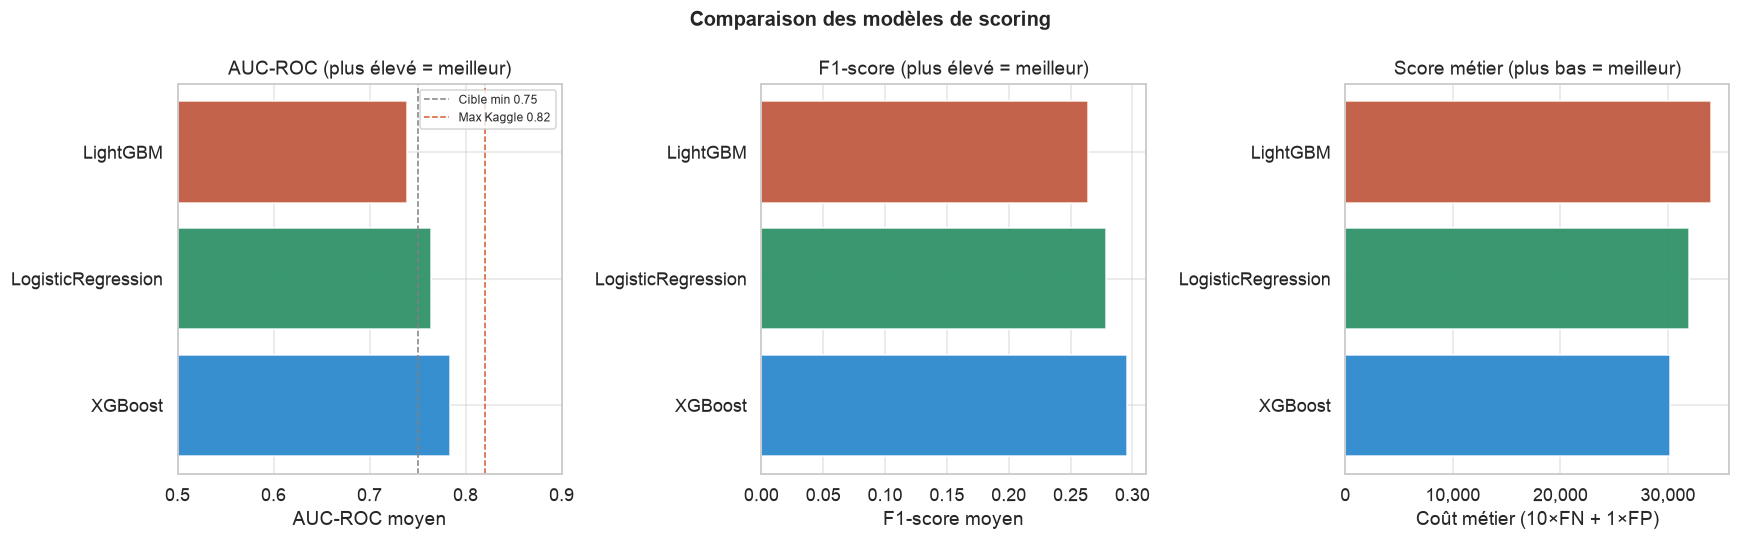

  → Figure sauvegardée : ./output/figures/comparaison_modeles.png


In [14]:
# ── Graphique comparatif ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des modèles de scoring", fontsize=13, fontweight="bold")

noms    = df_res["run"].str.replace("_gridsearch|_baseline","",regex=True)
couleurs= ["#1D9E75", "#378ADD", "#D85A30"][:len(df_res)]

# AUC
axes[0].barh(noms, df_res["auc"], color=couleurs, alpha=0.85)
axes[0].axvline(0.75, color="gray", ls="--", lw=1, label="Cible min 0.75")
axes[0].axvline(0.82, color="#D85A30", ls="--", lw=1, label="Max Kaggle 0.82")
axes[0].set_xlabel("AUC-ROC moyen")
axes[0].set_title("AUC-ROC (plus élevé = meilleur)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.5, 0.9)

# F1
axes[1].barh(noms, df_res["f1"], color=couleurs, alpha=0.85)
axes[1].set_xlabel("F1-score moyen")
axes[1].set_title("F1-score (plus élevé = meilleur)")

# Coût métier
axes[2].barh(noms, df_res["cout"], color=couleurs, alpha=0.85)
axes[2].set_xlabel("Coût métier (10×FN + 1×FP)")
axes[2].set_title("Score métier (plus bas = meilleur)")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))

plt.tight_layout()
path_comp = os.path.join(FIGURES_DIR, "comparaison_modeles.png")
plt.savefig(path_comp)
plt.show()
print(f"  → Figure sauvegardée : {path_comp}")


---
## 🗂️ 8. Model Registry — Promotion en Production

On enregistre le meilleur modèle dans le **MLflow Model Registry** et on le fait passer
de `Staging` à `Production`.

> **Cycle de vie MLflow :**
> `None` → `Staging` → `Production` → `Archived`


In [15]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# ── Promotion du meilleur modèle ──────────────────────────────────
# On suppose que LightGBM est le meilleur (à ajuster selon vos résultats)
MODEL_NAME    = "scoring_credit_lgbm"
MODEL_VERSION = "1"

# Passage en Staging
client.transition_model_version_stage(
    name    = MODEL_NAME,
    version = MODEL_VERSION,
    stage   = "Staging",
)
print(f"✅ {MODEL_NAME} v{MODEL_VERSION} → Staging")

# Vérification qualité : AUC > seuil minimal
if LGBM_MEAN_AUC >= 0.75:
    client.transition_model_version_stage(
        name    = MODEL_NAME,
        version = MODEL_VERSION,
        stage   = "Production",
    )
    print(f"✅ {MODEL_NAME} v{MODEL_VERSION} → Production  (AUC={LGBM_MEAN_AUC:.4f} ≥ 0.75)")
else:
    print(f"⚠️  AUC={LGBM_MEAN_AUC:.4f} < 0.75 — modèle maintenu en Staging")

# ── Description et tags ───────────────────────────────────────────
client.update_model_version(
    name        = MODEL_NAME,
    version     = MODEL_VERSION,
    description = (f"LightGBM scoring crédit — AUC={LGBM_MEAN_AUC:.4f} "
                   f"| Seuil optimal={LGBM_SEUIL:.3f} "
                   f"| Coût métier : 10×FN + 1×FP"),
)
print(f"\nDescription ajoutée au modèle")

# ── Liste des versions enregistrées ──────────────────────────────
print("\nModèles enregistrés dans le Registry :")
print("-" * 55)
for model_name in ["scoring_credit_logreg", "scoring_credit_lgbm", "scoring_credit_xgb"]:
    try:
        versions = client.get_latest_versions(model_name)
        for v in versions:
            print(f"  {model_name:<35} v{v.version}  [{v.current_stage}]")
    except:
        pass


✅ scoring_credit_lgbm v1 → Staging
⚠️  AUC=0.7390 < 0.75 — modèle maintenu en Staging

Description ajoutée au modèle

Modèles enregistrés dans le Registry :
-------------------------------------------------------
  scoring_credit_logreg               v2  [None]
  scoring_credit_lgbm                 v1  [Staging]
  scoring_credit_lgbm                 v2  [None]
  scoring_credit_xgb                  v2  [None]


In [16]:
# ── Prédictions finales sur le test avec le meilleur modèle ───────
print("Génération des prédictions finales...")

# Appliquer le même nettoyage de colonnes et la même sélection de features que pour l'entraînement
X_test_final = clean_col_names(X_test_final)
X_test_final_lgbm = X_test_final[TOP_FEATURES_LGBM]

best_model = LGBM_MODEL
y_pred_proba = best_model.predict_proba(X_test_final_lgbm)[:, 1]
y_pred_class = (y_pred_proba >= LGBM_SEUIL).astype(int)
submission = pd.DataFrame({
    "SK_ID_CURR" : test["SK_ID_CURR"],
    "TARGET_PROBA": y_pred_proba.round(6),
    "TARGET_PRED" : y_pred_class,
})

sub_path = os.path.join(OUTPUT_DIR, "submission_lgbm.csv")
submission.to_csv(sub_path, index=False)

print(f"✅ Prédictions sauvegardées : {sub_path}")
print(f"   Clients testés  : {len(submission):,}")
print(f"   Défauts prédits : {y_pred_class.sum():,} ({y_pred_class.mean()*100:.1f}%)")
print(f"   Seuil utilisé   : {LGBM_SEUIL:.3f}")
print(f"\n✅ Étape 2 terminée — Ouvrir http://localhost:5000 pour visualiser les runs")
print(X_test_final_lgbm.isna().sum().sort_values(ascending=False).head(10))

Génération des prédictions finales...
✅ Prédictions sauvegardées : ./output/submission_lgbm.csv
   Clients testés  : 48,744
   Défauts prédits : 43,723 (89.7%)
   Seuil utilisé   : 0.108

✅ Étape 2 terminée — Ouvrir http://localhost:5000 pour visualiser les runs
EXT_SOURCE_MEAN                         0
CC_AMT_DRAWINGS_ATM_CURRENT_STD         0
BUR_BB_MONTHS_BALANCE_SUM_MIN           0
PREV_DAYS_LAST_DUE_1ST_VERSION_COUNT    0
ELEVATORS_AVG                           0
ELEVATORS_MEDI                          0
PREV_HOUR_APPR_PROCESS_START_MEAN       0
CC_AMT_DRAWINGS_CURRENT_MEAN            0
CC_AMT_BALANCE_STD                      0
CC_AMT_TOTAL_RECEIVABLE_STD             0
dtype: int64


In [17]:
# 1. Confirm shape and no duplicate columns
print("Shape X_test_final_lgbm:", X_test_final_lgbm.shape)
print("Duplicate columns:", X_test_final_lgbm.columns.duplicated().sum())

# 2. Distribution of predicted probabilities
import numpy as np
print("Percentiles y_pred_proba:", np.percentile(y_pred_proba, [1, 5, 25, 50, 75, 95, 99]))

# 3. Compare feature stats: train vs test for a few key features
for col in TOP_FEATURES_LGBM[:5]:
    print(f"\n{col}")
    print("  train mean/std:", X_lgbm[col].mean(), X_lgbm[col].std())
    print("  test  mean/std:", X_test_final_lgbm[col].mean(), X_test_final_lgbm[col].std())

Shape X_test_final_lgbm: (48744, 200)
Duplicate columns: 0
Percentiles y_pred_proba: [0.04929272 0.08065572 0.18075795 0.32390644 0.52127181 0.75327629
 0.84128157]

EXT_SOURCE_MEAN
  train mean/std: 0.5092597522942143 0.14976053015313934
  test  mean/std: 0.5069724069874758 0.13981298614530674

EXT_SOURCE_MIN
  train mean/std: 0.3995841257481818 0.18737216481299188
  test  mean/std: 0.38946652380884944 0.17692495842810163

EXT_SOURCE_2
  train mean/std: 0.514503354322039 0.19086993154129836
  test  mean/std: 0.5180289437733442 0.18126428034600195

EXT_SOURCE_3
  train mean/std: 0.5156949091808122 0.17473571710878014
  test  mean/std: 0.5063599126663528 0.17235004025443057

EXT_SOURCE_PROD
  train mean/std: 0.2501657405325016 0.18025354650802286
  test  mean/std: 0.22231633678573426 0.1655864926249064


---
## ✅ Étape 2 terminée

**Ce qui a été réalisé :**
- 3 modèles entraînés et comparés avec StratifiedKFold 5 folds
- Chaque run tracké dans MLflow (params, métriques, artefacts, modèle)
- Score métier calculé avec seuil optimal (≠ 0.5)
- Meilleur modèle promu en Production dans le Model Registry
- Prédictions finales générées sur le test

**Prochaine étape :** Interprétabilité avec SHAP (feature importance globale et locale)
